Import Library

In [8]:
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np


Hubungkan dengan google drive

In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

Visualization

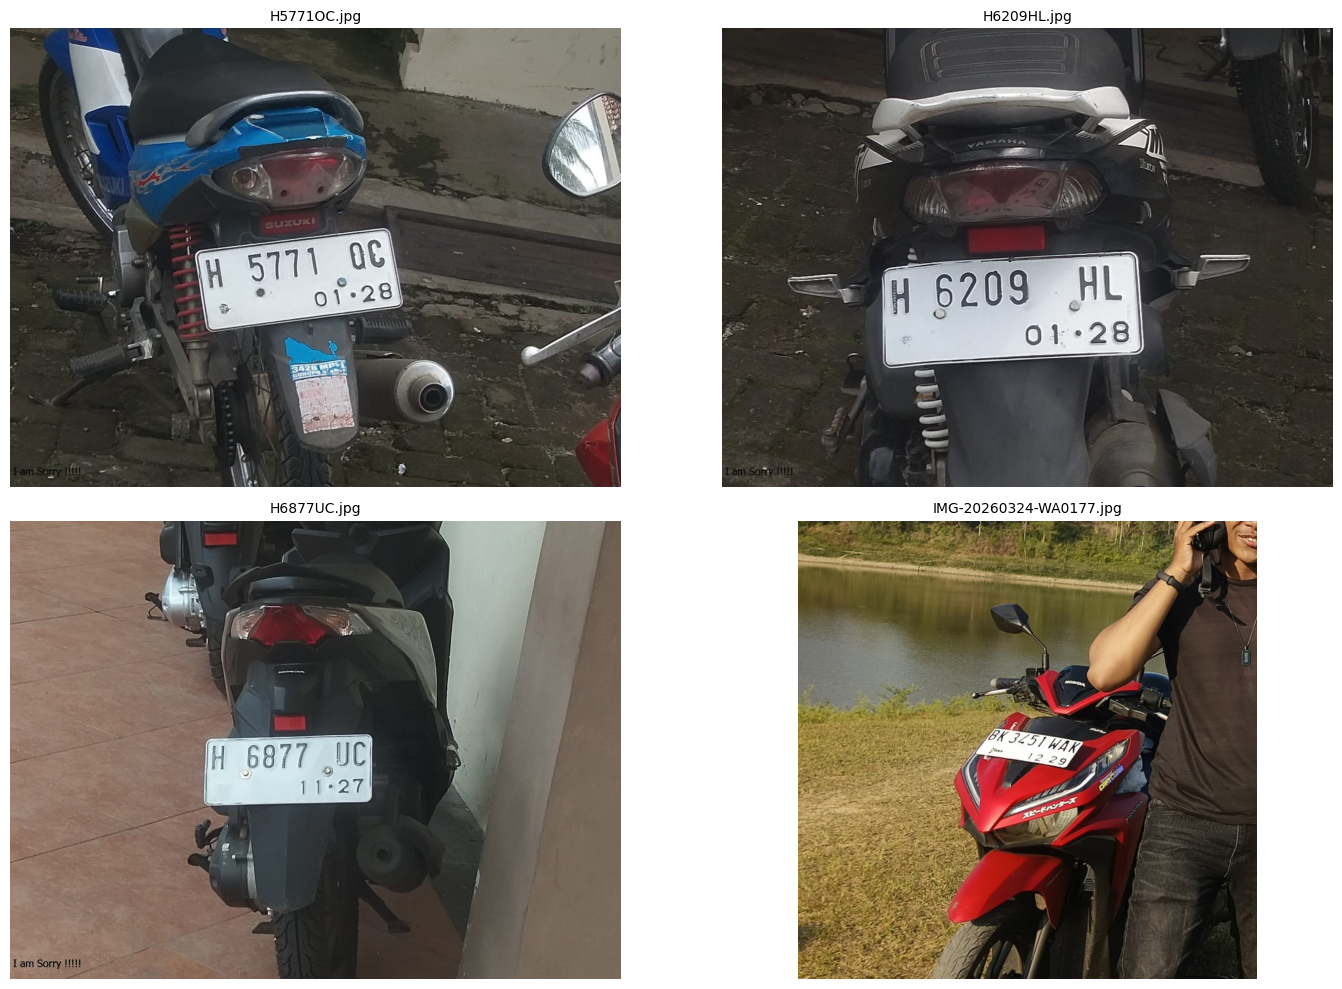

In [10]:
folder_path_raw_image = '../dataset/raw/'
image_names = os.listdir(folder_path_raw_image)[:4]

images_data = []

plt.figure(figsize=(15, 10))
for i, image_name in enumerate(image_names):
    full_image_path = os.path.join(folder_path_raw_image, image_name)
    image = cv2.imread(full_image_path)
    if image is not None:
        images_data.append(image)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 2, i + 1)
        plt.imshow(image_rgb)
        plt.title(image_name, fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

Grayscle

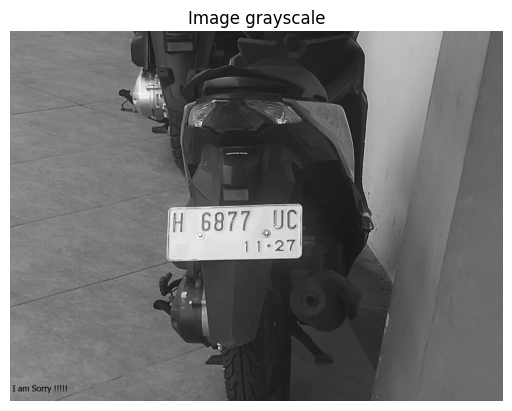

In [11]:
img_gray = cv2.cvtColor(images_data[2], cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.title("Image grayscale")
plt.axis('off')
plt.show()

blur

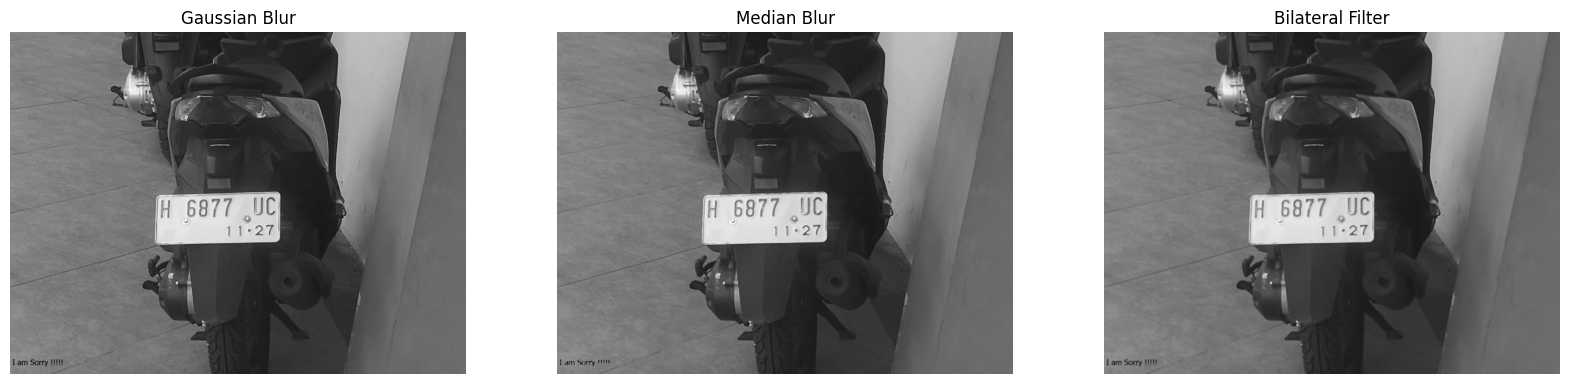

In [12]:
blur_gaussian = cv2.GaussianBlur(img_gray, (3, 3), 0)

blur_median = cv2.medianBlur(img_gray, 5)

blur_bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)


plt.figure(figsize=(20,10))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(blur_gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(blur_median, cv2.COLOR_BGR2RGB))
plt.title("Median Blur")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(blur_bilateral, cv2.COLOR_BGR2RGB))
plt.title("Bilateral Filter")
plt.axis('off')

plt.show()

lokalisasi

2


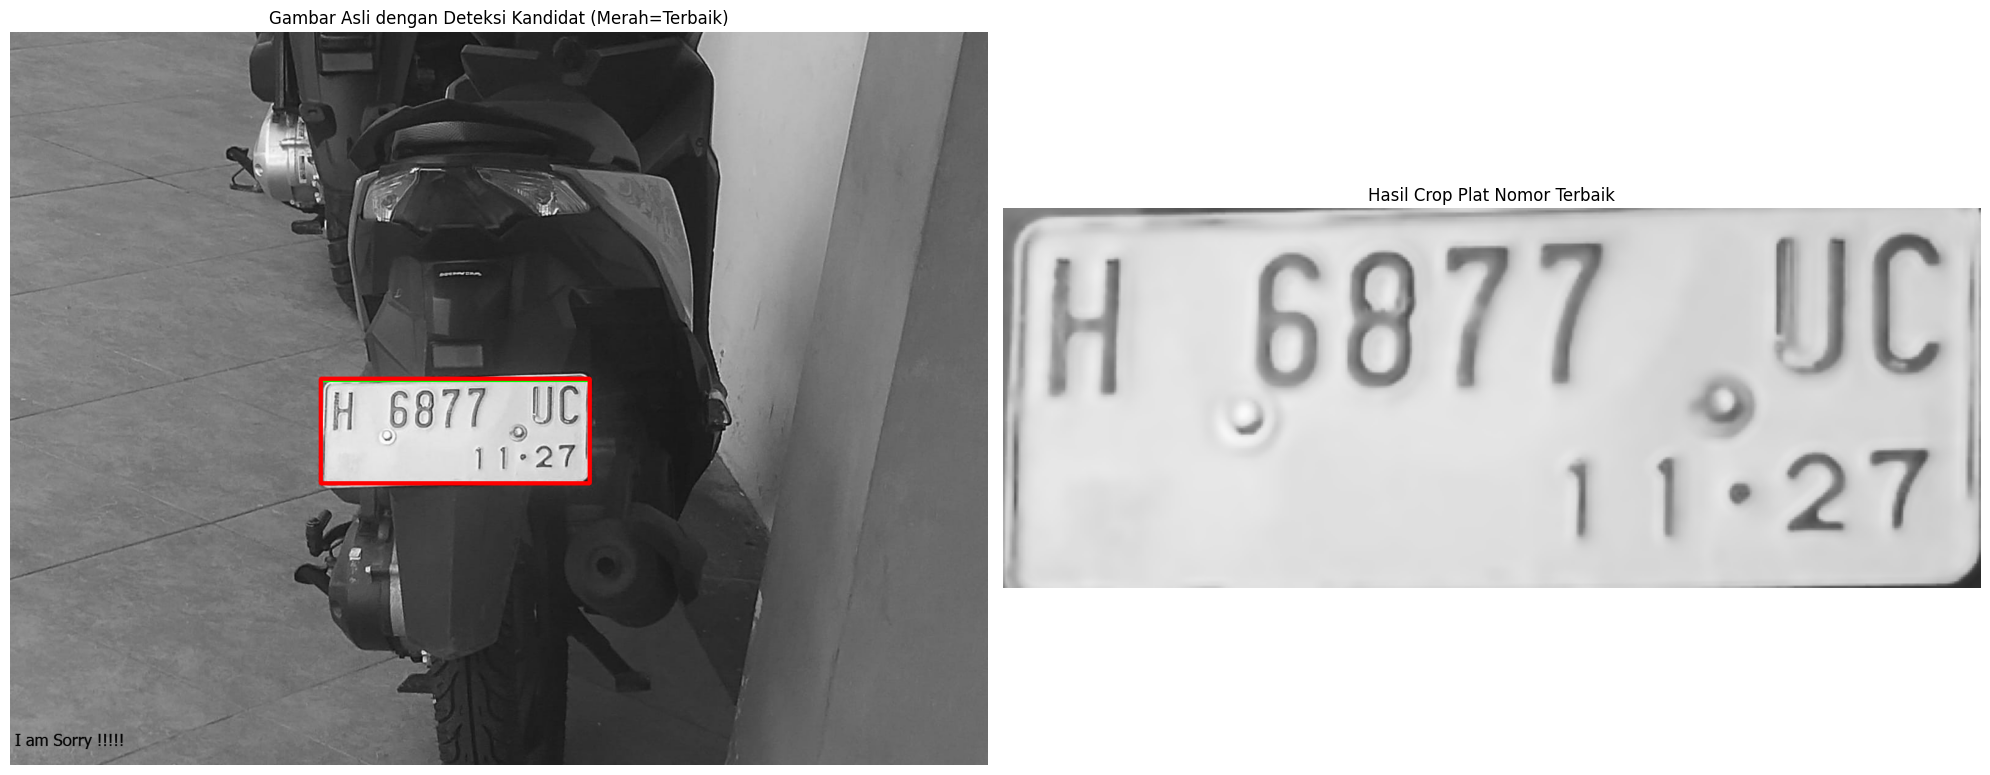

In [13]:
def automatic_canny_thresholds(image):
    median = np.median(image)

    # Atur threshold berdasarkan median
    lower = int(max(0, (1.0 - 0.33) * median))
    upper = int(min(255, (1.0 + 0.33) * median))
    return lower, upper

def crop_plate(img_input):

    # 2. Deteksi Tepi Adaptif
    lower, upper = automatic_canny_thresholds(img_input)
    edged = cv2.Canny(img_input, lower, upper)

    # 3. Temukan Kontur
    contours, _ = cv2.findContours(edged, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:50]

    results = []

    for contour in contours:
        area = cv2.contourArea(contour)
        if area < 500: # Abaikan kontur yang terlalu kecil (noise)
            continue

        # Pendekatan poligon
        peri = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

        x, y, w, h = cv2.boundingRect(approx)

        # 5. Filter Rasio Aspek Plat (Kunci Utama)
        # Plat nomor Indonesia (motor) biasanya sekitar 25cm x 10cm, rasio ~2.5:1
        # Kita beri toleransi, misalnya 2.0:1 hingga 4.0:1
        aspect_ratio = float(w) / h

        # Jika kontur memiliki 4-8 sudut (toleransi untuk plat miring/terpotong)
        if 4 <= len(approx) <= 8:
            if 2.0 < aspect_ratio < 4.5:
                candidate = img_input[y:y+h, x:x+w]
                results.append(((x, y, w, h), candidate))

    # Ambil kandidat pertama yang memenuhi kriteria (biasanya yang terbaik karena urutan area)
    if results:
        best_candidate_loc, best_candidate_img = results[0]
        return best_candidate_img, results

    return None, []

plate_img, all_candidates = crop_plate(blur_bilateral)

fig = plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
img_detected = cv2.cvtColor(img_gray, cv2.COLOR_BGR2RGB).copy()
if all_candidates:
    for (x, y, w, h), _ in all_candidates:
        cv2.rectangle(img_detected, (x, y), (x+w, y+h), (0, 255, 0), 3)
    (x, y, w, h), _ = all_candidates[0]
    cv2.rectangle(img_detected, (x, y), (x+w, y+h), (255, 0, 0), 5)

print(len(all_candidates))
plt.imshow(img_detected)
plt.title('Gambar Asli dengan Deteksi Kandidat (Merah=Terbaik)')
plt.axis('off')

plt.subplot(1, 2, 2)
if plate_img is not None:
    plate_img_rgb = cv2.cvtColor(plate_img, cv2.COLOR_BGR2RGB)
    plt.imshow(plate_img_rgb)
    plt.title('Hasil Crop Plat Nomor Terbaik')
else:
    plt.imshow(np.zeros((100, 300, 3), dtype=np.uint8))
    plt.title('Plat Nomor Tidak Ditemukan')
plt.axis('off')

plt.tight_layout()
plt.show()




Morphology


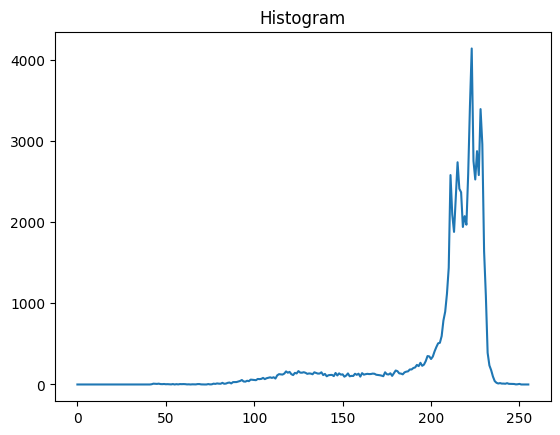

In [14]:
calc_hist = cv2.calcHist([plate_img], [0], None, [256], [0, 256])

plt.plot(calc_hist)
plt.title("Histogram")
plt.show()

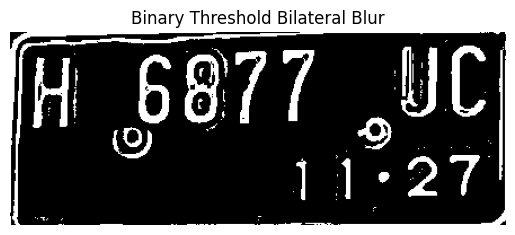

In [15]:
thresh_binary = cv2.adaptiveThreshold(plate_img, 255,
                                     cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY_INV, 11, 2)
plt.imshow(thresh_binary, cmap='gray')
plt.title("Binary Threshold Bilateral Blur")
plt.axis('off')
plt.show()


# _, thresh_binary = cv2.threshold(img_grayscale, 127, 255, cv2.THRESH_BINARY)
# plt.imshow(thresh_binary, cmap='gray')
# plt.title("Binary Threshold Gaussian Blur")
# plt.axis('off')
# plt.show()



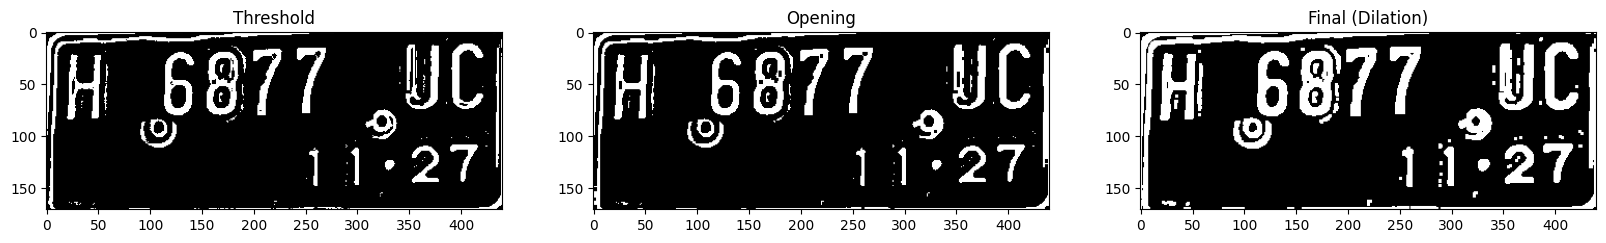

[[  0   0   0 ...   0 255 255]
 [  0   0   0 ...   0 255 255]
 [  0   0   0 ...   0 255 255]
 ...
 [255 255   0 ... 255 255 255]
 [255 255   0 ... 255   0   0]
 [255 255   0 ...   0   0   0]]


In [16]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Closing dulu untuk menutup celah/lubang di dalam karakter
closing = cv2.morphologyEx(thresh_binary, cv2.MORPH_CLOSE, kernel)

# Baru dilate untuk menebalkan
final_result = cv2.dilate(closing, kernel, iterations=1)

plt.figure(figsize=(20, 10))

plt.subplot(1,3,1)
plt.imshow(thresh_binary, cmap='gray')
plt.title("Threshold")

plt.subplot(1,3,2)
plt.imshow(closing, cmap='gray')
plt.title("Opening")

plt.subplot(1,3,3)
plt.imshow(final_result, cmap='gray')
plt.title("Final (Dilation)")

plt.show()

print(final_result)

segmentation

In [17]:
contours, _ = cv2.findContours(
    final_result,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


In [18]:
# char_candidates = []

# for cnt in contours:
#     x, y, w, h = cv2.boundingRect(cnt)

#     # filter ukuran (tuning penting)
#     if h > 15 and w > 10 and w <100:
#         char_candidates.append((x, y, w, h))


char_candidates = []

plate_h, plate_w = final_result.shape

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    ratio = h / w
    area = w * h

    if (
        50 < h < 120 and
        10 < w < 100 and
        1 < ratio < 5 and
        500 < area < 5000 and
        y < plate_h * 0.8
    ):
        char_candidates.append((x, y, w, h))

In [19]:
char_candidates = sorted(char_candidates, key=lambda b: b[0])

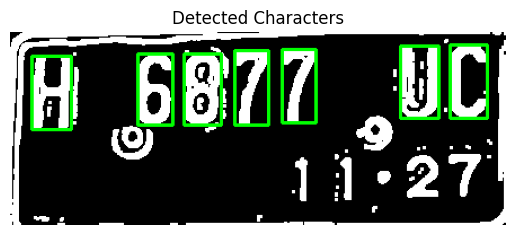

In [20]:
img_debug = cv2.cvtColor(final_result, cv2.COLOR_GRAY2BGR)

for (x, y, w, h) in char_candidates:
    cv2.rectangle(img_debug, (x, y), (x+w, y+h), (0,255,0), 2)

plt.imshow(img_debug)
plt.title("Detected Characters")
plt.axis('off')
plt.show()

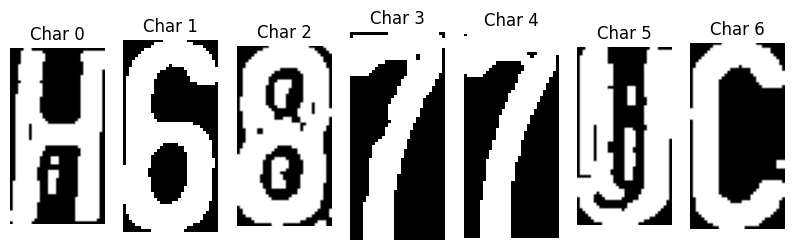

In [21]:
characters = []

for (x, y, w, h) in char_candidates:
    char = final_result[y:y+h, x:x+w]
    characters.append(char)


plt.figure(figsize=(10,3))

for i, char in enumerate(characters):
    plt.subplot(1, len(characters), i+1)
    plt.imshow(char, cmap='gray')
    plt.title(f"Char {i}")
    plt.axis('off')

plt.show()

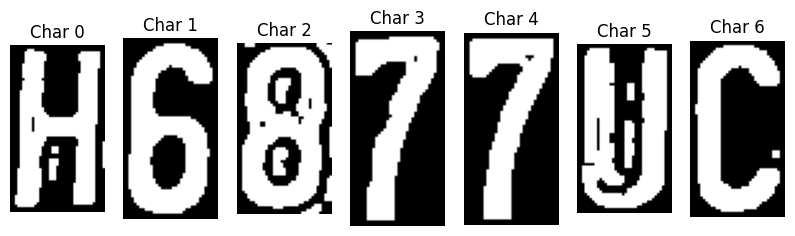

In [22]:
characters = []

for (x, y, w, h) in char_candidates:
    pad = 2

    y1 = max(y - pad, 0)
    y2 = min(y + h + pad, final_result.shape[0])
    x1 = max(x - pad, 0)
    x2 = min(x + w + pad, final_result.shape[1])

    char = final_result[y1:y2, x1:x2]

    characters.append(char)


plt.figure(figsize=(10,3))

for i, char in enumerate(characters):
    plt.subplot(1, len(characters), i+1)
    plt.imshow(char, cmap='gray')
    plt.title(f"Char {i}")
    plt.axis('off')

plt.show()

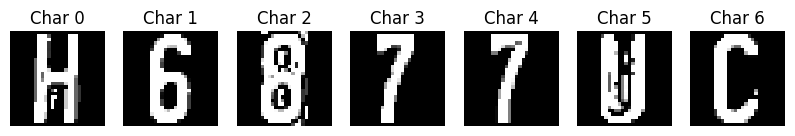

In [23]:
def resize_with_padding(img, target_size=28):
    h, w = img.shape

    # hitung scaling
    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # resize tanpa distorsi
    resized = cv2.resize(img, (new_w, new_h))

    # buat canvas hytam
    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    # hitung posisi mid
    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2

    # tempel ke mid
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas


plt.figure(figsize=(10,3))

for i, char in enumerate(characters):
    plt.subplot(1, len(characters), i+1)
    char = resize_with_padding(char)
    plt.imshow(char, cmap='gray')
    plt.title(f"Char {i}")
    plt.axis('off')

plt.show()
